# ML1 — EDA & Feature Engineering

**Objective:** Extract fill history from the DB, explore the data, engineer lag/rolling features, and export `data/training_features.parquet` for model training.

**Output:** `data/training_features.parquet`  
**Validation:** ≥ 8 features created, dataset documented, no future leakage

---

## Prerequisites

Run these checks in pgAdmin or psql before proceeding:

```sql
-- ≥ 30 days of data
SELECT MIN(measured_at), MAX(measured_at), COUNT(*) FROM fill_history;

-- aggregated stats populated
SELECT COUNT(*) FROM aggregated_hourly_stats;

-- container types seeded
SELECT * FROM container_type;
```

In [9]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
from dotenv import load_dotenv
from statsmodels.graphics.tsaplots import plot_acf

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100

load_dotenv(dotenv_path=os.path.join('.', '.env'))

# Forward ports first : kubectl port-forward svc/postgres-postgresql 5432:5432 -n datalake

conn = psycopg2.connect(
    host=os.environ['POSTGRES_HOST'],
    port=os.environ.get('POSTGRES_PORT', 5432),
    database=os.environ['POSTGRES_DB'],
    user=os.environ['POSTGRES_USER'],
    password=os.environ['POSTGRES_PASSWORD'],
)
print('Connected to DB')

Connected to DB


## 1. Data Extraction

In [10]:
print('Extracting fill_history...')
df_hist = pd.read_sql("""
    SELECT
        fh.container_id,
        fh.measured_at,
        fh.fill_rate,
        c.capacity_liters,
        c.type_id,
        c.zone_id
    FROM fill_history fh
    JOIN containers c ON c.key_container = fh.container_id
    WHERE NOT fh.is_outlier
      AND c.is_active = true
    ORDER BY fh.container_id, fh.measured_at
""", conn, parse_dates=['measured_at'])

print(f'Rows extracted  : {len(df_hist):,}')
print(f'Containers      : {df_hist.container_id.nunique():,}')
print(f'Date range      : {df_hist.measured_at.min()} → {df_hist.measured_at.max()}')
df_hist.head()

Extracting fill_history...
Rows extracted  : 8,555,787
Containers      : 2,000
Date range      : 2026-05-14 16:00:00 → 2026-06-13 16:00:00


,container_id,measured_at,fill_rate,capacity_liters,type_id,zone_id
0,1,2026-05-14 16:00:00,21.16,750.0,2,1
1,1,2026-05-14 16:10:00,21.40,750.0,2,1
2,1,2026-05-14 16:20:00,21.82,750.0,2,1
3,1,2026-05-14 16:30:00,21.96,750.0,2,1
4,1,2026-05-14 16:40:00,22.25,750.0,2,1


In [11]:
print('Extracting zone densities...')
df_zones = pd.read_sql("""
    SELECT
        z.key_zone,
        COUNT(c.key_container)::numeric /
            NULLIF(ST_Area(z.polygon::geography)::numeric / 1e6, 0) AS density_km2
    FROM zones z
    LEFT JOIN containers c ON ST_Within(c.location, z.polygon) AND c.is_active = true
    WHERE z.polygon IS NOT NULL
    GROUP BY z.key_zone
""", conn)

print(f'Zones with polygon: {len(df_zones)}')
df_zones.head()

Extracting zone densities...
Zones with polygon: 5


,key_zone,density_km2
0,1,206.532441
1,2,148.814228
2,3,55.595054
3,4,108.593627
4,5,137.181011


## 2. Exploratory Data Analysis

In [12]:
print('=== Basic stats ===')
print(df_hist.describe())

print('\n=== Missing values ===')
print(df_hist.isnull().sum())

=== Basic stats ===
       container_id                    measured_at     fill_rate  \
count  8.555787e+06                        8555787  8.555787e+06   
mean   1.000528e+03  2026-05-29 15:59:18.868890368  3.883761e+01   
min    1.000000e+00            2026-05-14 16:00:00  0.000000e+00   
25%    5.010000e+02            2026-05-22 04:00:00  2.183000e+01   
50%    1.001000e+03            2026-05-29 16:00:00  3.858000e+01   
75%    1.501000e+03            2026-06-06 04:00:00  5.550000e+01   
max    2.000000e+03            2026-06-13 16:00:00  8.000000e+01   
std    5.773626e+02                            NaN  1.993112e+01   

       capacity_liters       type_id       zone_id  
count     8.555787e+06  8.555787e+06  8.555787e+06  
mean      1.157502e+03  3.508365e+00  3.000063e+00  
min       5.000000e+02  1.000000e+00  1.000000e+00  
25%       7.500000e+02  2.000000e+00  2.000000e+00  
50%       1.000000e+03  3.000000e+00  3.000000e+00  
75%       1.500000e+03  5.000000e+00  4.000000e+0

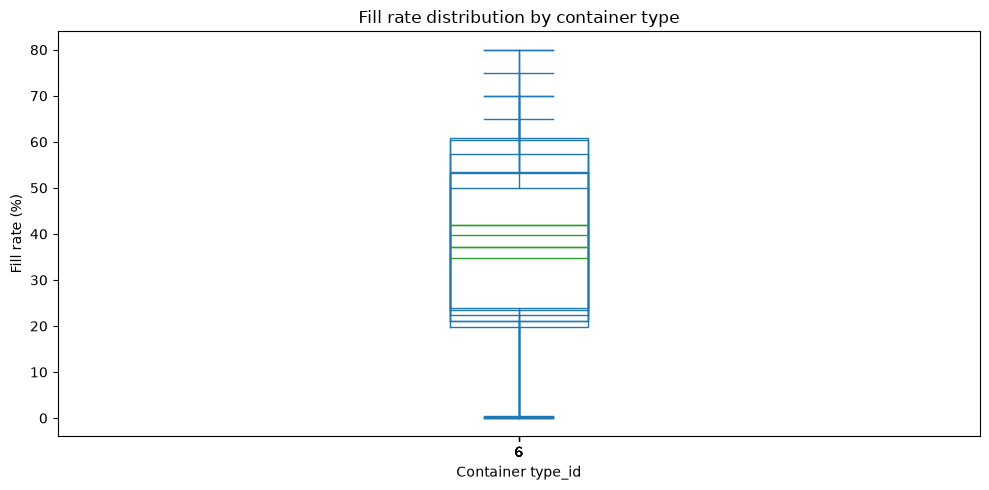

In [13]:
# Plot 1 — Fill rate distribution per container type
fig, ax = plt.subplots(figsize=(10, 5))
df_hist.groupby('type_id')['fill_rate'].plot.box(ax=ax, vert=True)
ax.set_title('Fill rate distribution by container type')
ax.set_xlabel('Container type_id')
ax.set_ylabel('Fill rate (%)')
plt.tight_layout()
plt.show()

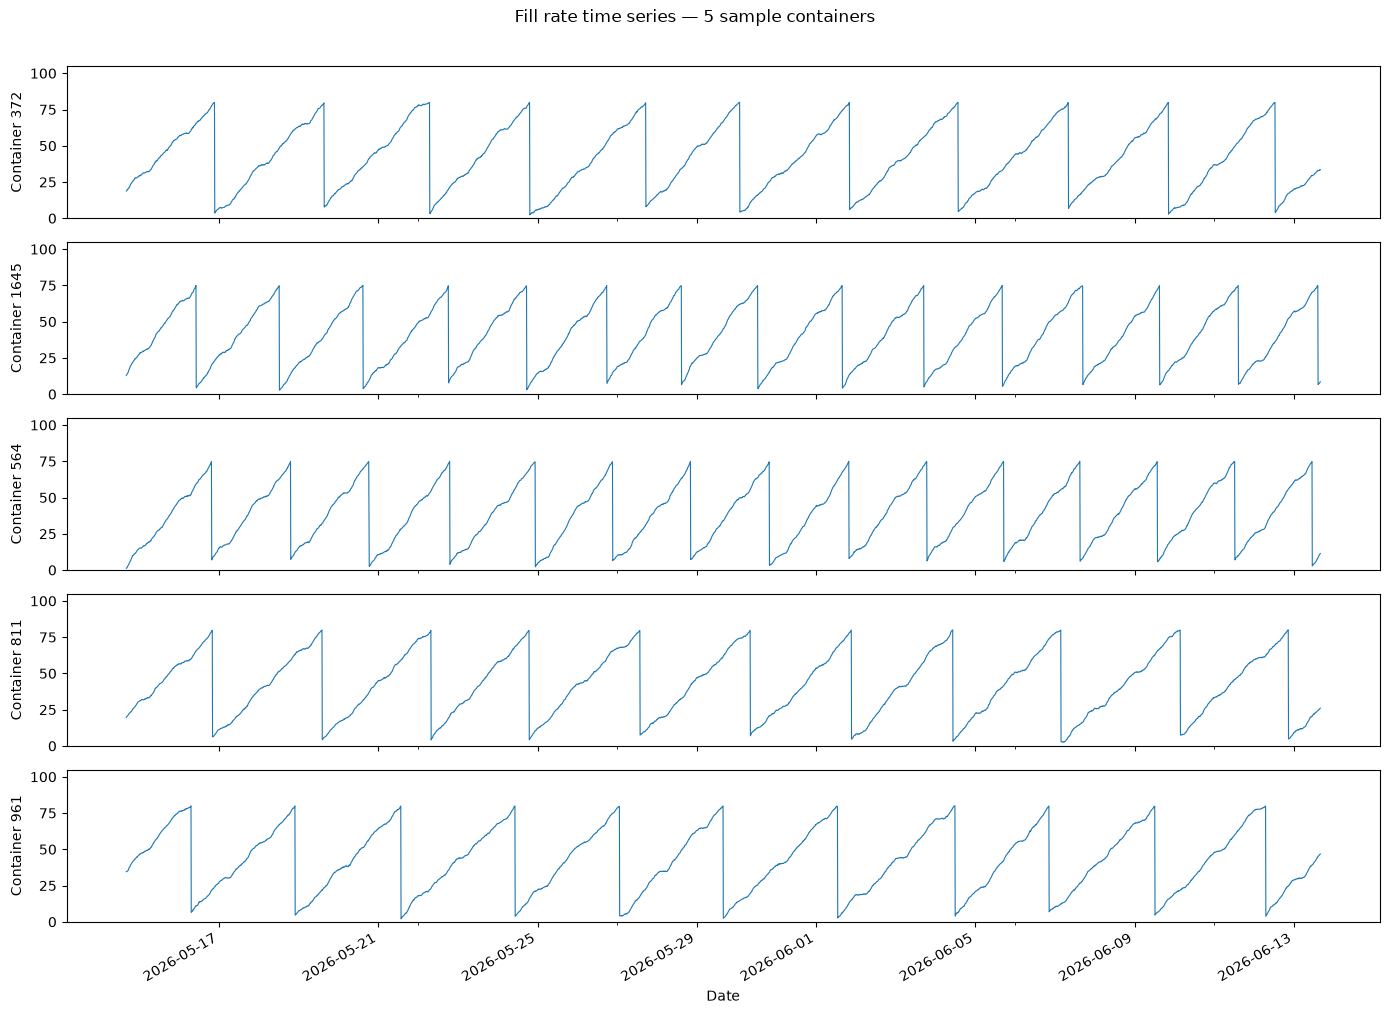

In [14]:
# Plot 2 — Time series for 5 sample containers
sample_ids = df_hist['container_id'].value_counts().head(5).index.tolist()
fig, axes = plt.subplots(len(sample_ids), 1, figsize=(14, 10), sharex=True)

for ax, cid in zip(axes, sample_ids):
    sub = df_hist[df_hist.container_id == cid].set_index('measured_at')
    sub['fill_rate'].plot(ax=ax, linewidth=0.8)
    ax.set_ylabel(f'Container {cid}')
    ax.set_ylim(0, 105)

axes[-1].set_xlabel('Date')
fig.suptitle('Fill rate time series — 5 sample containers', y=1.01)
plt.tight_layout()
plt.show()

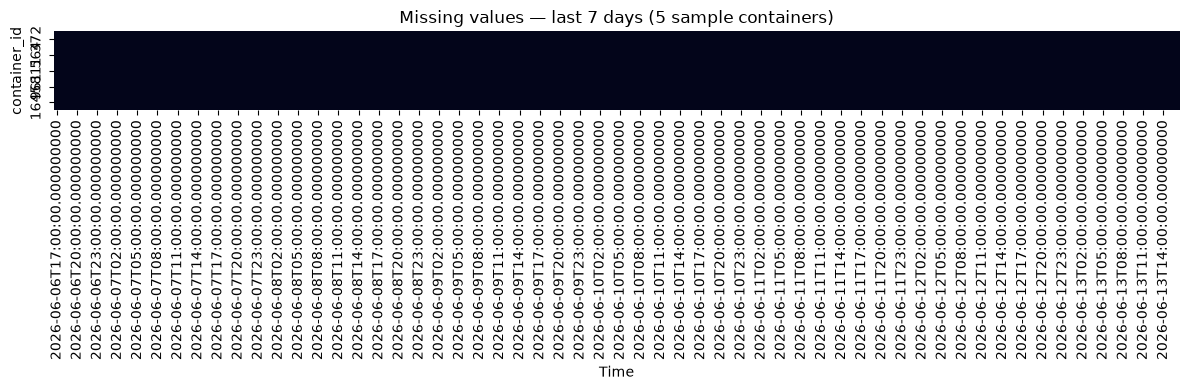

In [15]:
# Plot 3 — Missing value heatmap (sample of containers)
pivot_sample = (
    df_hist[df_hist.container_id.isin(sample_ids)]
    .pivot_table(index='measured_at', columns='container_id', values='fill_rate')
    .resample('1h').mean()
    .tail(168)  # last 7 days
)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(pivot_sample.isnull().T, ax=ax, cbar=False, yticklabels=True)
ax.set_title('Missing values — last 7 days (5 sample containers)')
ax.set_xlabel('Time')
plt.tight_layout()
plt.show()

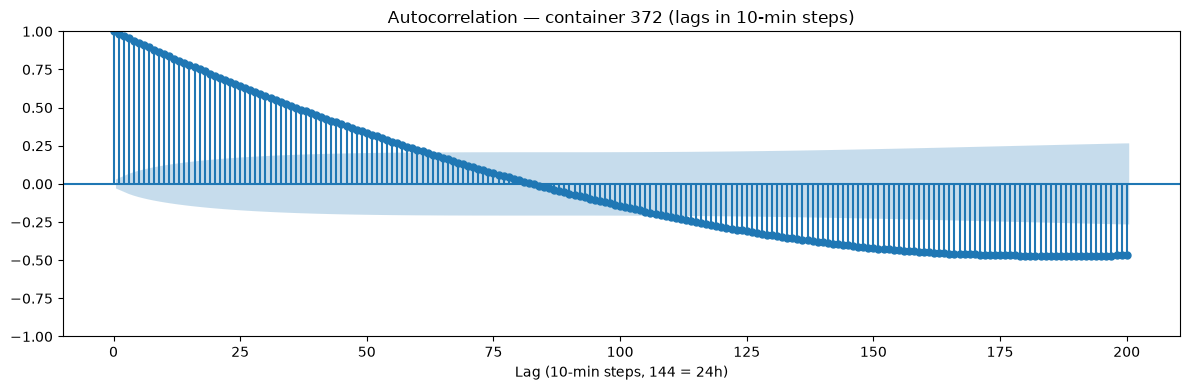

In [16]:
# Plot 4 — Autocorrelation (validates that lag features have signal)
one_container = df_hist[df_hist.container_id == sample_ids[0]].set_index('measured_at')

fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(one_container['fill_rate'].dropna(), lags=200, ax=ax, alpha=0.05)
ax.set_title(f'Autocorrelation — container {sample_ids[0]} (lags in 10-min steps)')
ax.set_xlabel('Lag (10-min steps, 144 = 24h)')
plt.tight_layout()
plt.show()

## 3. Feature Engineering

| Feature | Type | Description |
|---|---|---|
| `hour` | temporal | Hour of day (0–23) |
| `day_of_week` | temporal | Day of week (0=Mon, 6=Sun) |
| `day_of_month` | temporal | Day of month (1–31) |
| `is_weekend` | temporal | 1 if Saturday or Sunday |
| `is_peak_hour` | temporal | 1 if hour in {7,8,9,17,18,19} |
| `fill_rate_1h_ago` | lag | Fill rate ~1h before (shift 6 rows at 10-min cadence) |
| `fill_rate_24h_ago` | lag | Fill rate ~24h before (shift 144 rows) |
| `fill_rate_7d_ago` | lag | Fill rate ~7 days before (shift 1008 rows) |
| `fill_rate_24h_avg` | rolling | Trailing 24h mean (no future leakage via shift(1) first) |
| `fill_rate_7d_avg` | rolling | Trailing 7-day mean |
| `fill_rate_change_rate` | derivative | Δ fill_rate per 10-min step over the last 1h |
| `capacity_liters` | container | Physical capacity |
| `type_id` | container | Waste type category |
| `density_km2` | zone | Containers per km² in the zone |

In [17]:
df_hist = df_hist.sort_values(['container_id', 'measured_at']).reset_index(drop=True)
g = df_hist.groupby('container_id')['fill_rate']

# Compute actual sampling cadence so shift constants work regardless of seed-data interval
median_interval_min = (
    df_hist.groupby('container_id')['measured_at']
    .apply(lambda s: s.diff().dt.total_seconds().median() / 60)
    .median()
)
SHIFT_1H  = max(1, round(60            / median_interval_min))
SHIFT_24H = max(1, round(24 * 60       / median_interval_min))
SHIFT_7D  = max(1, round(7 * 24 * 60  / median_interval_min))

print(f'Median interval  : {median_interval_min:.1f} min')
print(f'Readings per day : {24*60/median_interval_min:.1f}')
print(f'Shifts — 1h={SHIFT_1H}, 24h={SHIFT_24H}, 7d={SHIFT_7D}')

# ── Temporal ────────────────────────────────────────────────────────────────
df_hist['hour']         = df_hist['measured_at'].dt.hour
df_hist['day_of_week']  = df_hist['measured_at'].dt.dayofweek
df_hist['day_of_month'] = df_hist['measured_at'].dt.day
df_hist['is_weekend']   = (df_hist['day_of_week'] >= 5).astype(int)
df_hist['is_peak_hour'] = df_hist['hour'].isin([7, 8, 9, 17, 18, 19]).astype(int)

# ── Lag features ─────────────────────────────────────────────────────────────
df_hist['fill_rate_1h_ago']  = g.shift(SHIFT_1H)
df_hist['fill_rate_24h_ago'] = g.shift(SHIFT_24H)
df_hist['fill_rate_7d_ago']  = g.shift(SHIFT_7D)

# ── Rolling averages (shift(1) first → no leakage of current reading) ────────
df_hist['fill_rate_24h_avg'] = (
    g.transform(lambda s: s.shift(1).rolling(SHIFT_24H, min_periods=max(2, SHIFT_24H // 10)).mean())
)
df_hist['fill_rate_7d_avg'] = (
    g.transform(lambda s: s.shift(1).rolling(SHIFT_7D, min_periods=max(2, SHIFT_7D // 10)).mean())
)
df_hist['fill_rate_change_rate'] = (
    g.transform(lambda s: (s - s.shift(SHIFT_1H)) / SHIFT_1H)
)

print('Lag/rolling features computed')

Median interval  : 10.0 min
Readings per day : 144.0
Shifts — 1h=6, 24h=144, 7d=1008
Lag/rolling features computed


In [18]:
# Zone density join
df_hist = df_hist.merge(df_zones, left_on='zone_id', right_on='key_zone', how='left')
df_hist['density_km2'] = df_hist['density_km2'].fillna(0)

# Target: fill_rate 24h in the future
df_hist['target'] = g.shift(-SHIFT_24H)

print('Target and zone density added')

Target and zone density added


In [19]:
FEATURE_COLS = [
    'hour', 'day_of_week', 'day_of_month', 'is_weekend', 'is_peak_hour',
    'fill_rate_1h_ago', 'fill_rate_24h_ago', 'fill_rate_7d_ago',
    'fill_rate_24h_avg', 'fill_rate_7d_avg', 'fill_rate_change_rate',
    'capacity_liters', 'type_id', 'density_km2',
]

# Diagnose NaN counts before dropping — helps understand data volume issues
nan_counts = df_hist[FEATURE_COLS + ['target']].isnull().sum()
print('=== NaN counts per feature (before dropna) ===')
print(nan_counts.to_string())
print(f'\nTotal rows before dropna : {len(df_hist):,}')

df_clean = df_hist[FEATURE_COLS + ['target', 'container_id', 'measured_at']].dropna()
rows_dropped = len(df_hist) - len(df_clean)
print(f'Rows dropped by dropna   : {rows_dropped:,}')
print(f'Rows remaining           : {len(df_clean):,}')

if len(df_clean) == 0:
    print()
    print('ERROR: no rows survived dropna.')
    print('Most likely cause: fill_history has < 7 days of data, so all')
    print('  fill_rate_7d_ago (shift 1008) and fill_rate_7d_avg values are NaN.')
    print()
    print('Check how many days of data are available:')
    print('  SELECT MIN(measured_at), MAX(measured_at),')
    print('         COUNT(*), COUNT(DISTINCT container_id)')
    print('  FROM fill_history;')
    print()
    print('You need at least 8 days (7d lag + 1d target window) per container.')
    raise ValueError('Empty training set — not enough fill_history data. See message above.')

print(f'\nFeatures     : {len(FEATURE_COLS)}')
print(f'Date range   : {df_clean.measured_at.min()} → {df_clean.measured_at.max()}')
print(f'Containers   : {df_clean.container_id.nunique():,}')
print(f'Target range : {df_clean.target.min():.1f} – {df_clean.target.max():.1f}')

assert len(FEATURE_COLS) >= 8, 'Need at least 8 features (ML1 validation criterion)'
df_clean.describe()

=== NaN counts per feature (before dropna) ===
hour                           0
day_of_week                    0
day_of_month                   0
is_weekend                     0
is_peak_hour                   0
fill_rate_1h_ago           12000
fill_rate_24h_ago         288000
fill_rate_7d_ago         2016000
fill_rate_24h_avg          28000
fill_rate_7d_avg          200000
fill_rate_change_rate      12000
capacity_liters                0
type_id                        0
density_km2                    0
target                    288000

Total rows before dropna : 8,555,787
Rows dropped by dropna   : 2,304,000
Rows remaining           : 6,251,787

Features     : 14
Date range   : 2026-05-21 16:10:00 → 2026-06-12 16:00:00
Containers   : 2,000
Target range : 1.6 – 80.0


,hour,day_of_week,day_of_month,is_weekend,is_peak_hour,fill_rate_1h_ago,fill_rate_24h_ago,fill_rate_7d_ago,fill_rate_24h_avg,fill_rate_7d_avg,fill_rate_change_rate,capacity_liters,type_id,density_km2,target,container_id,measured_at
count,6.251787e+06,6.251787e+06,6.251787e+06,6.251787e+06,6.251787e+06,6.251787e+06,6.251787e+06,6.251787e+06,6.251787e+06,6.251787e+06,6.251787e+06,6.251787e+06,6.251787e+06,6.251787e+06,6.251787e+06,6.251787e+06,6251787
mean,1.148346e+01,3.030218e+00,1.571147e+01,2.736418e-01,2.494984e-01,3.880386e+01,3.896142e+01,3.880536e+01,3.889678e+01,3.891850e+01,-6.105612e-04,1.157503e+03,3.508315e+00,1.313429e+02,3.879620e+01,1.000538e+03,2026-06-01 16:42:39.916678144
min,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.570000e+00,1.710000e+00,0.000000e+00,8.222708e+00,3.123181e+01,-1.305333e+01,5.000000e+02,1.000000e+00,5.559505e+01,1.570000e+00,1.000000e+00,2026-05-21 16:10:00
25%,5.000000e+00,1.000000e+00,6.000000e+00,0.000000e+00,0.000000e+00,2.157000e+01,2.174000e+01,2.189000e+01,3.252493e+01,3.638796e+01,1.500000e-01,7.500000e+02,2.000000e+00,1.085936e+02,2.173000e+01,5.010000e+02,2026-05-27 05:10:00
50%,1.100000e+01,3.000000e+00,1.100000e+01,0.000000e+00,0.000000e+00,3.844000e+01,3.874000e+01,3.854000e+01,3.731035e+01,3.830192e+01,2.616667e-01,1.000000e+03,3.000000e+00,1.371810e+02,3.849000e+01,1.001000e+03,2026-06-01 16:40:00
75%,1.800000e+01,5.000000e+00,2.600000e+01,1.000000e+00,0.000000e+00,5.568000e+01,5.584000e+01,5.536000e+01,4.369764e+01,4.137263e+01,4.250000e-01,1.500000e+03,5.000000e+00,1.488142e+02,5.553000e+01,1.501000e+03,2026-06-07 04:20:00
max,2.300000e+01,6.000000e+00,3.100000e+01,1.000000e+00,1.000000e+00,8.000000e+01,8.000000e+01,8.000000e+01,7.448882e+01,5.082319e+01,1.631667e+00,2.000000e+03,6.000000e+00,2.065324e+02,8.000000e+01,2.000000e+03,2026-06-12 16:00:00
std,6.927876e+00,1.964793e+00,1.048478e+01,4.458273e-01,4.327228e-01,2.007447e+01,2.007324e+01,1.987518e+01,1.037454e+01,3.285748e+00,1.829529e+00,5.427408e+02,1.673287e+00,4.949262e+01,1.995725e+01,5.773672e+02,NaN


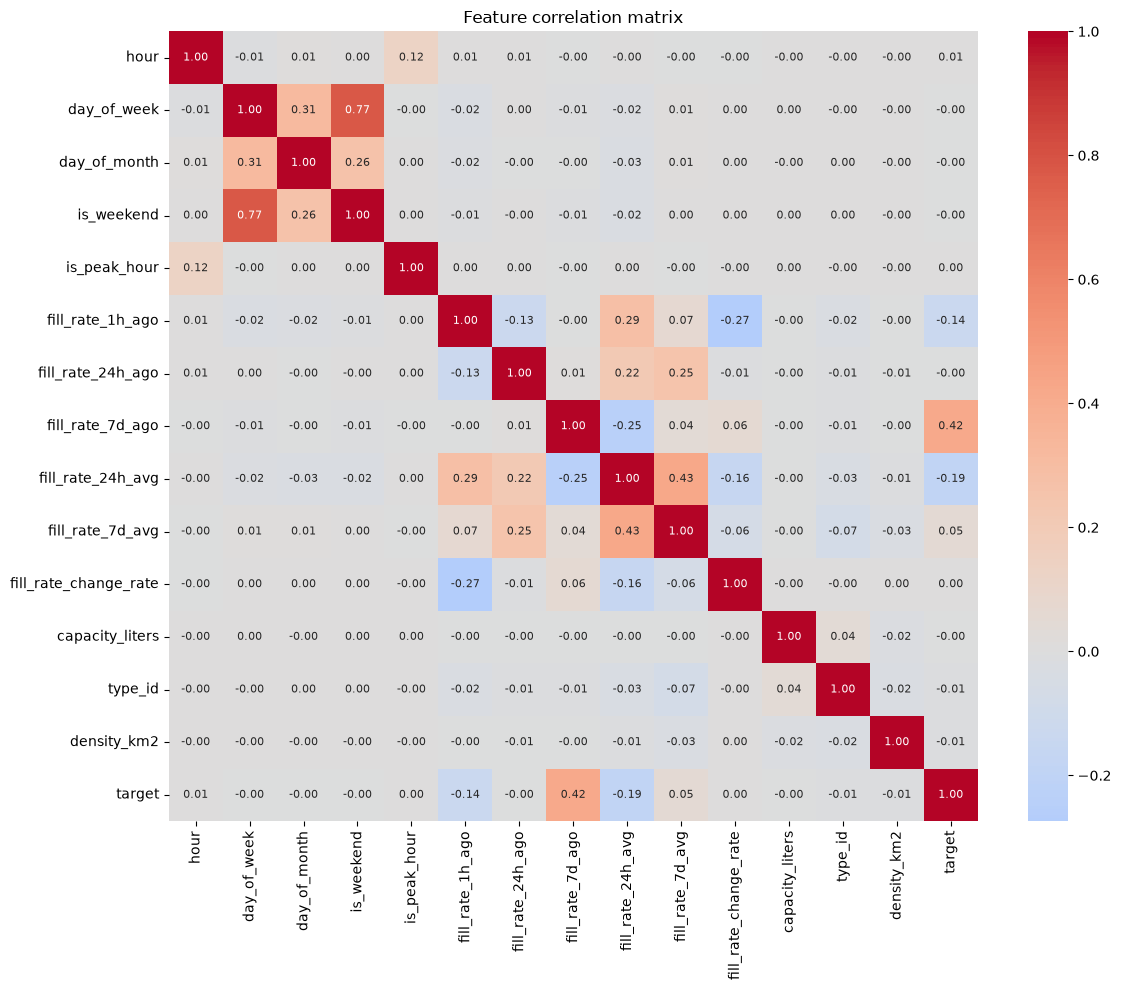

In [20]:
# Feature correlation heatmap (optional, informational)
fig, ax = plt.subplots(figsize=(12, 10))
corr = df_clean[FEATURE_COLS + ['target']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Feature correlation matrix')
plt.tight_layout()
plt.show()

In [21]:
os.makedirs('data', exist_ok=True)
df_clean.to_parquet('data/training_features.parquet', index=False)
print(f'Saved: data/training_features.parquet ({len(df_clean):,} rows, {len(FEATURE_COLS)} features)')

Saved: data/training_features.parquet (6,251,787 rows, 14 features)


In [22]:
conn.close()
print('Done — proceed to 02_training.ipynb')

Done — proceed to 02_training.ipynb
